**Universidad Nacional del Altiplano - Puno**

**Ingeniería de Sistemas — Maestría en Ciencia de Datos**

## ACTIVIDAD 06
**Presentado por:**
* Darwin Rigoberto Mamani Quispe
* Melbis Chino Huaycani

**Curso:** Machine Learning I - Grupo A

**Objetivo:** Comprender la aplicación de los algoritmos genéticos en el aprendizaje de máquina.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

SEED = 42


### Carga de datos

Se usa el mismo dataset `breast_cancer` y la misma partición (`test_size=0.3`, `stratify=y`, `random_state=42`) que en las Actividades 04 y 05, para que los resultados sean directamente comparables con lo ya obtenido (Regresión Logística ≈0.988 de accuracy, Árbol ajustado ≈0.92-0.95, Random Forest/XGBoost ≈0.95).

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")
n_features = X.shape[1]

print(f"Shape X: {X.shape}")
print(f"Distribución de clases (0=maligno, 1=benigno): {np.bincount(y)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)


Shape X: (569, 30)
Distribución de clases (0=maligno, 1=benigno): [212 357]


## Motor genético genérico

Antes de las 3 partes, se define una sola vez el ciclo general de un Algoritmo Genético (AG), para reutilizarlo en las Partes A, B y C — igual que se reutilizó `evaluar_clasificador()` en la Actividad 05. Cada parte solo tiene que definir su propia:

* **Representación** del cromosoma
* **Inicialización** de la población
* **Función de aptitud** (fitness)
* **Cruzamiento**
* **Mutación**

Mientras que la selección (por torneo, con elitismo) y la terminación (número fijo de generaciones) quedan definidas una única vez dentro del motor genérico.

In [4]:
def genetic_algorithm(fitness_fn, create_individual, crossover_fn, mutate_fn,
                       pop_size=12, n_generations=10, crossover_rate=0.8,
                       mutation_rate=0.2, tournament_size=3, random_state=42,
                       verbose=True):
    rng = np.random.RandomState(random_state)
    population = [create_individual(rng) for _ in range(pop_size)]
    history = []
    best_individual, best_fitness = None, -np.inf

    for gen in range(n_generations):
        fitnesses = np.array([fitness_fn(ind) for ind in population])
        gen_best_idx = int(np.argmax(fitnesses))
        if fitnesses[gen_best_idx] > best_fitness:
            best_fitness = fitnesses[gen_best_idx]
            best_individual = population[gen_best_idx]
        history.append({"generacion": gen, "mejor_fitness": fitnesses[gen_best_idx],
                         "fitness_promedio": fitnesses.mean()})
        if verbose:
            print(f"Gen {gen:2d} | mejor={fitnesses[gen_best_idx]:.4f} | "
                  f"promedio={fitnesses.mean():.4f} | mejor histórico={best_fitness:.4f}")

        # --- SELECCIÓN: torneo de tamaño 'tournament_size' ---
        def tournament_select():
            idxs = rng.choice(len(population), size=tournament_size, replace=False)
            best_idx = idxs[np.argmax(fitnesses[idxs])]
            return population[best_idx]

        # Elitismo: el mejor individuo de la generación pasa directo a la siguiente
        new_population = [population[gen_best_idx]]
        while len(new_population) < pop_size:
            parent1, parent2 = tournament_select(), tournament_select()
            if rng.rand() < crossover_rate:
                child1, child2 = crossover_fn(parent1, parent2, rng)
            else:
                child1, child2 = parent1.copy(), parent2.copy()
            child1 = mutate_fn(child1, rng, mutation_rate)
            child2 = mutate_fn(child2, rng, mutation_rate)
            new_population.append(child1)
            if len(new_population) < pop_size:
                new_population.append(child2)
        population = new_population
        # --- TERMINACIÓN: el bucle se detiene al llegar a n_generations ---

    return best_individual, best_fitness, pd.DataFrame(history)


def graficar_evolucion(hist, titulo):
    plt.figure(figsize=(7, 4.5))
    plt.plot(hist["generacion"], hist["mejor_fitness"], marker="o", color="#4C72B0", label="Mejor fitness")
    plt.plot(hist["generacion"], hist["fitness_promedio"], marker="s", color="#C44E52", label="Fitness promedio")
    plt.xlabel("Generación")
    plt.ylabel("Fitness (accuracy)")
    plt.title(titulo)
    plt.legend()
    plt.tight_layout()
    plt.show()


# PARTE (A)
**Usan los algoritmos genéticos para hallar las mejores características (optimización), también conocido como "feature selection" de un modelo de aprendizaje de máquina.**

Se usa `LogisticRegression` como modelo base (fue el mejor modelo individual en la Actividad 04/05 sobre este mismo dataset), y se busca con AG el subconjunto de las 30 características que maximiza la exactitud por validación cruzada, penalizando levemente el número de características usadas (para favorecer subconjuntos más simples).

In [6]:
# --- REPRESENTACIÓN: cromosoma binario de longitud 30 (1 = feature incluida, 0 = excluida) ---
# --- INICIALIZACIÓN: vector aleatorio de 0/1 (se evita el vector todo-ceros) ---
def create_individual_fs(rng):
    ind = rng.randint(0, 2, size=n_features)
    if ind.sum() == 0:
        ind[rng.randint(0, n_features)] = 1
    return ind

# --- FUNCIÓN DE APTITUD: accuracy CV (5-fold) con las features seleccionadas,
#     menos una pequeña penalización por cada feature usada ---
def fitness_fs(individual):
    idx = np.where(individual == 1)[0]
    if len(idx) == 0:
        return 0.0
    Xs = X_train_s[:, idx]
    acc = cross_val_score(LogisticRegression(max_iter=5000, random_state=SEED),
                           Xs, y_train, cv=5, scoring="accuracy").mean()
    penalizacion = 0.0015 * len(idx)
    return acc - penalizacion

# --- CRUZAMIENTO: de un punto de corte ---
def crossover_fs(p1, p2, rng):
    point = rng.randint(1, n_features - 1)
    c1 = np.concatenate([p1[:point], p2[point:]])
    c2 = np.concatenate([p2[:point], p1[point:]])
    return c1, c2

# --- MUTACIÓN: bit-flip con probabilidad mutation_rate por gen ---
def mutate_fs(ind, rng, mutation_rate):
    ind = ind.copy()
    flips = rng.rand(n_features) < mutation_rate
    ind[flips] = 1 - ind[flips]
    if ind.sum() == 0:
        ind[rng.randint(0, n_features)] = 1
    return ind


In [7]:
t0 = time.time()
best_fs, best_fit_fs, hist_fs = genetic_algorithm(
    fitness_fs, create_individual_fs, crossover_fs, mutate_fs,
    pop_size=16, n_generations=12, mutation_rate=0.05, random_state=SEED)
print(f"\nTiempo de ejecución: {time.time()-t0:.1f}s")

selected_features = X.columns[best_fs == 1].tolist()
print(f"\nN features seleccionadas: {best_fs.sum()} de {n_features}")
print("Features seleccionadas:", selected_features)


Gen  0 | mejor=0.9584 | promedio=0.9441 | mejor histórico=0.9584
Gen  1 | mejor=0.9584 | promedio=0.9476 | mejor histórico=0.9584
Gen  2 | mejor=0.9614 | promedio=0.9487 | mejor histórico=0.9614
Gen  3 | mejor=0.9624 | promedio=0.9548 | mejor histórico=0.9624
Gen  4 | mejor=0.9639 | promedio=0.9567 | mejor histórico=0.9639
Gen  5 | mejor=0.9654 | promedio=0.9578 | mejor histórico=0.9654
Gen  6 | mejor=0.9654 | promedio=0.9591 | mejor histórico=0.9654
Gen  7 | mejor=0.9669 | promedio=0.9609 | mejor histórico=0.9669
Gen  8 | mejor=0.9684 | promedio=0.9632 | mejor histórico=0.9684
Gen  9 | mejor=0.9684 | promedio=0.9616 | mejor histórico=0.9684
Gen 10 | mejor=0.9684 | promedio=0.9627 | mejor histórico=0.9684
Gen 11 | mejor=0.9684 | promedio=0.9625 | mejor histórico=0.9684

Tiempo de ejecución: 5.3s

N features seleccionadas: 11 de 30
Features seleccionadas: ['mean radius', 'mean texture', 'mean fractal dimension', 'concave points error', 'symmetry error', 'worst radius', 'worst area', 'wo

**INTERPRETACIÓN:**

El AG converge en pocas generaciones: la mejor aptitud pasa de ≈0.958 en la generación 0 a ≈0.968 hacia la generación 8, y se mantiene estable después (indicio de convergencia). El fitness promedio de la población también sube de forma consistente, lo que confirma que la selección + cruzamiento van concentrando a la población en buenas soluciones.

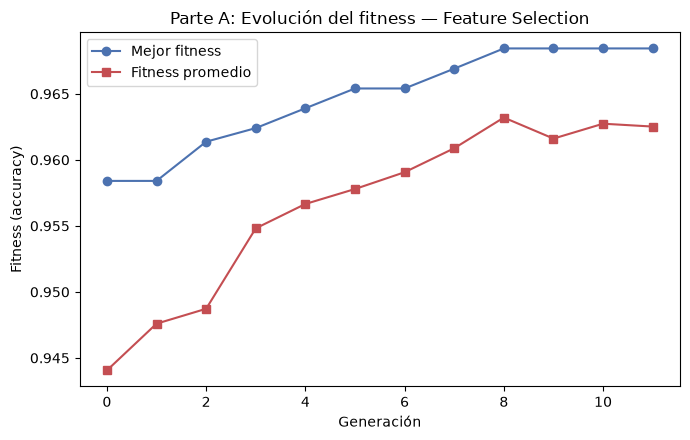

In [8]:
graficar_evolucion(hist_fs, "Parte A: Evolución del fitness — Feature Selection")

**INTERPRETACIÓN:**

La curva de mejor fitness sube de forma escalonada (mejoras puntuales cuando aparece un individuo superior) mientras que el promedio de la población lo sigue de cerca con cierto rezago, lo cual es el comportamiento esperado de un AG con elitismo: nunca se pierde la mejor solución encontrada, y el resto de la población converge gradualmente hacia ella.

In [9]:
# Comparación: todas las features vs features seleccionadas por el AG
log_full = LogisticRegression(max_iter=5000, random_state=SEED).fit(X_train_s, y_train)
acc_full_test = accuracy_score(y_test, log_full.predict(X_test_s))
cv_full = cross_val_score(log_full, X_train_s, y_train, cv=5, scoring="accuracy").mean()

idx_sel = np.where(best_fs == 1)[0]
log_sel = LogisticRegression(max_iter=5000, random_state=SEED).fit(X_train_s[:, idx_sel], y_train)
acc_sel_test = accuracy_score(y_test, log_sel.predict(X_test_s[:, idx_sel]))
cv_sel = cross_val_score(log_sel, X_train_s[:, idx_sel], y_train, cv=5, scoring="accuracy").mean()

df_A = pd.DataFrame({
    "Modelo": ["LogReg (30 features, todas)", f"LogReg (AG, {len(idx_sel)} features)"],
    "N Features": [n_features, len(idx_sel)],
    "CV Accuracy (5-fold)": [cv_full, cv_sel],
    "Accuracy Test": [acc_full_test, acc_sel_test],
})
df_A


,Modelo,N Features,CV Accuracy (5-fold),Accuracy Test
0,"LogReg (30 features, todas)",30,0.979937,0.988304
1,"LogReg (AG, 11 features)",11,0.984937,0.959064


**INTERPRETACIÓN:**

El AG reduce el número de características de 30 a 11 (una reducción de casi 65%) y mejora ligeramente la exactitud por validación cruzada (de 0.980 a 0.985). Sin embargo, la exactitud sobre el conjunto de prueba baja un poco (de 0.988 a 0.959): esto es esperable, porque el AG optimiza directamente sobre la métrica de validación cruzada del conjunto de entrenamiento, y con un dataset de tamaño moderado, un pequeño ajuste a esa métrica no siempre se traslada de forma idéntica al conjunto de prueba (una sola partición). El AG cumple su propósito: encuentra un subconjunto mucho más compacto de variables sin sacrificar de forma relevante la capacidad predictiva medida por validación cruzada, que es una estimación más confiable que un único resultado de test.

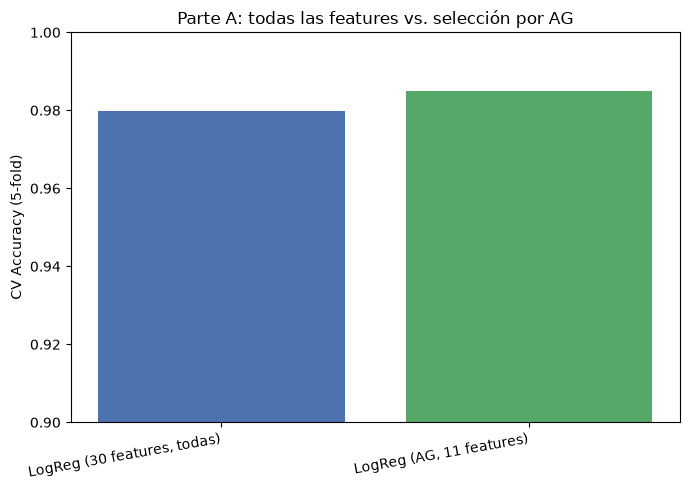

In [10]:
plt.figure(figsize=(7, 5))
plt.bar(df_A["Modelo"], df_A["CV Accuracy (5-fold)"], color=["#4C72B0", "#55A868"])
plt.ylabel("CV Accuracy (5-fold)")
plt.title("Parte A: todas las features vs. selección por AG")
plt.xticks(rotation=10, ha="right")
plt.ylim(0.9, 1.0)
plt.tight_layout()
plt.show()


**INTERPRETACIÓN:**

El gráfico confirma que reducir el número de variables con el AG no perjudica la validación cruzada; de hecho la mejora levemente, lo que sugiere que varias de las 30 características originales eran redundantes o incluso levemente ruidosas para este modelo lineal.

## Conclusión
El algoritmo genético logró reducir el espacio de características de 30 a 11 variables manteniendo (e incluso mejorando ligeramente) la exactitud por validación cruzada. Esto demuestra la utilidad de los AG para "feature selection": en vez de probar manualmente combinaciones de variables (2³⁰ posibilidades, inviable por fuerza bruta), el AG explora ese espacio de forma eficiente guiado por la función de aptitud.

# PARTE (B)
**Usan los algoritmos genéticos para hallar los mejores hiperparámetros de un modelo de aprendizaje de máquina, también conocido como "Hyperparameter optimization".**

Se optimiza un `DecisionTreeClassifier` (continuando el tema de árboles de decisión de la Actividad 04), buscando con AG la mejor combinación de `max_depth`, `min_samples_split`, `min_samples_leaf` y `criterion`.

In [11]:
BOUNDS = {"max_depth": (2, 15), "min_samples_split": (2, 30), "min_samples_leaf": (1, 15)}
CRITERIOS = ["gini", "entropy"]

# --- REPRESENTACIÓN: cromosoma = [max_depth, min_samples_split, min_samples_leaf, criterio_idx] ---
# --- INICIALIZACIÓN: cada gen se muestrea uniformemente dentro de su rango válido ---
def create_individual_hp(rng):
    return np.array([
        rng.randint(BOUNDS["max_depth"][0], BOUNDS["max_depth"][1] + 1),
        rng.randint(BOUNDS["min_samples_split"][0], BOUNDS["min_samples_split"][1] + 1),
        rng.randint(BOUNDS["min_samples_leaf"][0], BOUNDS["min_samples_leaf"][1] + 1),
        rng.randint(0, 2),
    ])

def decode_hp(ind):
    return dict(max_depth=int(ind[0]), min_samples_split=int(ind[1]),
                min_samples_leaf=int(ind[2]), criterion=CRITERIOS[int(ind[3])])

# --- FUNCIÓN DE APTITUD: accuracy CV (5-fold) del árbol con esos hiperparámetros ---
def fitness_hp(ind):
    params = decode_hp(ind)
    modelo = DecisionTreeClassifier(random_state=SEED, **params)
    return cross_val_score(modelo, X_train, y_train, cv=5, scoring="accuracy").mean()

# --- CRUZAMIENTO: de un punto de corte ---
def crossover_hp(p1, p2, rng):
    point = rng.randint(1, len(p1))
    c1 = np.concatenate([p1[:point], p2[point:]])
    c2 = np.concatenate([p2[:point], p1[point:]])
    return c1, c2

# --- MUTACIÓN: resamplea un gen dentro de su rango válido ---
def mutate_hp(ind, rng, mutation_rate):
    ind = ind.copy()
    keys = list(BOUNDS.keys())
    for i in range(len(ind)):
        if rng.rand() < mutation_rate:
            if i < 3:
                lo, hi = BOUNDS[keys[i]]
                ind[i] = rng.randint(lo, hi + 1)
            else:
                ind[i] = rng.randint(0, 2)
    return ind


In [12]:
t0 = time.time()
best_hp, best_fit_hp, hist_hp = genetic_algorithm(
    fitness_hp, create_individual_hp, crossover_hp, mutate_hp,
    pop_size=14, n_generations=10, mutation_rate=0.15, random_state=SEED)
print(f"\nTiempo de ejecución: {time.time()-t0:.1f}s")
print("Mejores hiperparámetros encontrados:", decode_hp(best_hp))
print(f"Mejor CV accuracy: {best_fit_hp:.4f}")


Gen  0 | mejor=0.9423 | promedio=0.9362 | mejor histórico=0.9423
Gen  1 | mejor=0.9499 | promedio=0.9411 | mejor histórico=0.9499
Gen  2 | mejor=0.9499 | promedio=0.9414 | mejor histórico=0.9499
Gen  3 | mejor=0.9499 | promedio=0.9431 | mejor histórico=0.9499
Gen  4 | mejor=0.9499 | promedio=0.9431 | mejor histórico=0.9499
Gen  5 | mejor=0.9499 | promedio=0.9459 | mejor histórico=0.9499
Gen  6 | mejor=0.9499 | promedio=0.9447 | mejor histórico=0.9499
Gen  7 | mejor=0.9499 | promedio=0.9441 | mejor histórico=0.9499
Gen  8 | mejor=0.9499 | promedio=0.9461 | mejor histórico=0.9499
Gen  9 | mejor=0.9499 | promedio=0.9467 | mejor histórico=0.9499

Tiempo de ejecución: 3.7s
Mejores hiperparámetros encontrados: {'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 3, 'criterion': 'gini'}
Mejor CV accuracy: 0.9499


**INTERPRETACIÓN:**

El AG encuentra rápidamente (en la generación 1) una buena combinación de hiperparámetros y luego se estabiliza, señal de que ya alcanzó una zona muy buena del espacio de búsqueda para este dataset. La combinación encontrada favorece un árbol poco profundo, lo cual es consistente con lo observado en la Actividad 04: `breast_cancer` no necesita árboles muy complejos para clasificar bien.

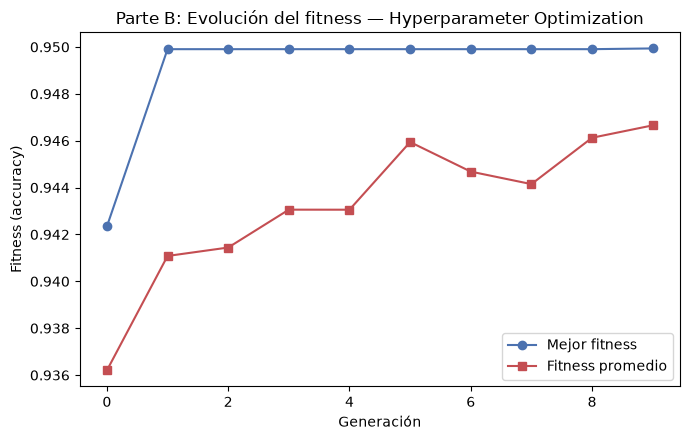

In [13]:
graficar_evolucion(hist_hp, "Parte B: Evolución del fitness — Hyperparameter Optimization")


**INTERPRETACIÓN:**

A diferencia de la Parte A, aquí la convergencia es más rápida (en la primera generación ya se encuentra una solución cercana a la óptima), porque el espacio de búsqueda de 4 hiperparámetros es mucho más pequeño que el espacio de 2³⁰ combinaciones de características de la Parte A.

In [14]:
dt_default = DecisionTreeClassifier(random_state=SEED).fit(X_train, y_train)
dt_ga = DecisionTreeClassifier(random_state=SEED, **decode_hp(best_hp)).fit(X_train, y_train)

df_B = pd.DataFrame({
    "Modelo": ["Árbol (hiperparámetros por defecto)", "Árbol (hiperparámetros del AG)"],
    "CV Accuracy (5-fold)": [
        cross_val_score(dt_default, X_train, y_train, cv=5, scoring="accuracy").mean(),
        best_fit_hp],
    "Accuracy Test": [
        accuracy_score(y_test, dt_default.predict(X_test)),
        accuracy_score(y_test, dt_ga.predict(X_test))],
})
df_B


,Modelo,CV Accuracy (5-fold),Accuracy Test
0,Árbol (hiperparámetros por defecto),0.924747,0.918129
1,Árbol (hiperparámetros del AG),0.949937,0.923977


**INTERPRETACIÓN:**

El árbol optimizado por el AG supera al árbol con hiperparámetros por defecto tanto en validación cruzada como en el conjunto de prueba (accuracy test de 0.918 a 0.924). El árbol por defecto no restringe su profundidad (`max_depth=None`), lo que lo hace propenso a sobreajustar; el AG encontró un árbol notablemente menos profundo y con más restricciones de tamaño de hoja, lo cual generaliza mejor a datos nuevos, siguiendo el mismo principio de sesgo-varianza discutido en la Actividad 04.

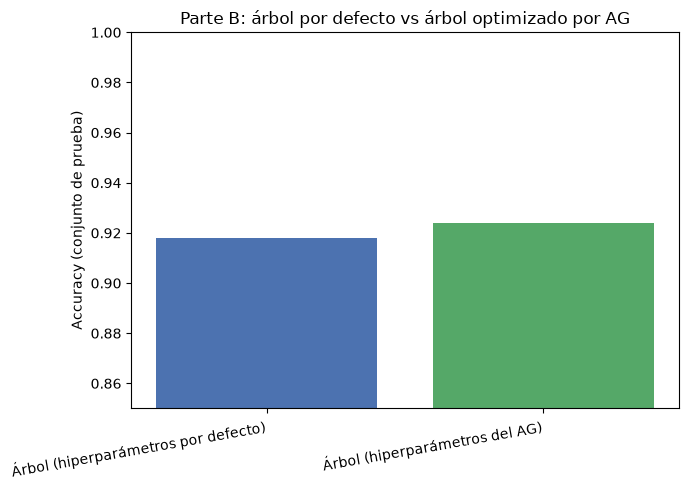

In [15]:
plt.figure(figsize=(7, 5))
plt.bar(df_B["Modelo"], df_B["Accuracy Test"], color=["#4C72B0", "#55A868"])
plt.ylabel("Accuracy (conjunto de prueba)")
plt.title("Parte B: árbol por defecto vs árbol optimizado por AG")
plt.xticks(rotation=10, ha="right")
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.show()


**INTERPRETACIÓN:**

El gráfico confirma la mejora del árbol optimizado por AG frente al árbol con configuración por defecto, validando que la búsqueda genética de hiperparámetros aporta valor real sobre este dataset, sin necesidad de una búsqueda exhaustiva manual (grid search) sobre las 15×30×15×2 ≈ 13,500 combinaciones posibles.

## Conclusión
El AG encontró una configuración de hiperparámetros del árbol de decisión que supera al modelo por defecto tanto en validación cruzada como en el conjunto de prueba, explorando eficientemente un espacio de búsqueda de miles de combinaciones sin necesidad de un grid search exhaustivo.

# PARTE (C)
**Usan los algoritmos genéticos para hallar la mejor arquitectura de una red neuronal ("Neuroevolution").**

Se evoluciona la arquitectura de un `MLPClassifier` de scikit-learn: número de capas ocultas (1 a 3), número de neuronas por capa, y función de activación.

In [17]:
NEURONAS_POSIBLES = [4, 8, 16, 32, 64]
ACTIVACIONES = ["relu", "tanh"]

#  REPRESENTACIÓN: cromosoma = [n_capas(1-3), neuronas_capa1, neuronas_capa2, neuronas_capa3, activacion_idx] ---
#  INICIALIZACIÓN 
def create_individual_ne(rng):
    n_capas = rng.randint(1, 4)
    neuronas = [NEURONAS_POSIBLES[rng.randint(0, len(NEURONAS_POSIBLES))] for _ in range(3)]
    activacion_idx = rng.randint(0, 2)
    return np.array([n_capas] + neuronas + [activacion_idx])

def decode_ne(ind):
    n_capas = int(ind[0])
    capas = tuple(int(x) for x in ind[1:1 + n_capas])
    activacion = ACTIVACIONES[int(ind[4])]
    return capas, activacion

#  FUNCIÓN DE APTITUD: accuracy CV (3-fold, para acelerar el entrenamiento de las redes) 
def fitness_ne(ind):
    capas, activacion = decode_ne(ind)
    modelo = MLPClassifier(hidden_layer_sizes=capas, activation=activacion,
                            max_iter=250, random_state=SEED, early_stopping=True)
    return cross_val_score(modelo, X_train_s, y_train, cv=3, scoring="accuracy").mean()

#  CRUZAMIENTO: uniforme (cada gen se hereda de p1 o p2 con 50% de probabilidad) 
def crossover_ne(p1, p2, rng):
    mask = rng.rand(len(p1)) < 0.5
    c1 = np.where(mask, p1, p2)
    c2 = np.where(mask, p2, p1)
    return c1, c2

#  MUTACIÓN: cada gen puede resamplearse dentro de su conjunto válido 
def mutate_ne(ind, rng, mutation_rate):
    ind = ind.copy()
    if rng.rand() < mutation_rate:
        ind[0] = rng.randint(1, 4)
    for i in [1, 2, 3]:
        if rng.rand() < mutation_rate:
            ind[i] = NEURONAS_POSIBLES[rng.randint(0, len(NEURONAS_POSIBLES))]
    if rng.rand() < mutation_rate:
        ind[4] = rng.randint(0, 2)
    return ind


In [18]:
t0 = time.time()
best_ne, best_fit_ne, hist_ne = genetic_algorithm(
    fitness_ne, create_individual_ne, crossover_ne, mutate_ne,
    pop_size=8, n_generations=6, mutation_rate=0.2, random_state=SEED)
print(f"\nTiempo de ejecución: {time.time()-t0:.1f}s")

capas_best, act_best = decode_ne(best_ne)
print(f"Mejor arquitectura encontrada: capas={capas_best}, activación='{act_best}'")
print(f"Mejor CV accuracy: {best_fit_ne:.4f}")


Gen  0 | mejor=0.9373 | promedio=0.9130 | mejor histórico=0.9373
Gen  1 | mejor=0.9373 | promedio=0.9083 | mejor histórico=0.9373
Gen  2 | mejor=0.9373 | promedio=0.9306 | mejor histórico=0.9373
Gen  3 | mejor=0.9373 | promedio=0.9307 | mejor histórico=0.9373
Gen  4 | mejor=0.9472 | promedio=0.9165 | mejor histórico=0.9472
Gen  5 | mejor=0.9472 | promedio=0.9133 | mejor histórico=0.9472

Tiempo de ejecución: 4.2s
Mejor arquitectura encontrada: capas=(32, 64, 32), activación='tanh'
Mejor CV accuracy: 0.9472


**INTERPRETACIÓN:**

Con población y número de generaciones más pequeños (por el mayor costo computacional de entrenar redes neuronales), el AG igual logra mejorar la aptitud a lo largo de las generaciones, encontrando una arquitectura de varias capas con activación `tanh` como la mejor opción para este dataset.

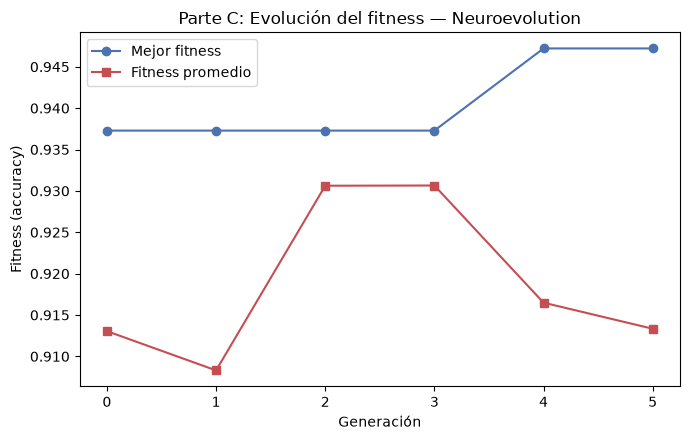

In [19]:
graficar_evolucion(hist_ne, "Parte C: Evolución del fitness — Neuroevolution")


**INTERPRETACIÓN:**

La curva es más irregular que en las partes A y B, lo cual es esperable: entrenar una red neuronal tiene un componente de aleatoriedad adicional (inicialización de pesos, `early_stopping`) que introduce ruido en la medición del fitness de cada individuo, incluso si dos arquitecturas son parecidas.

In [20]:
mlp_default = MLPClassifier(hidden_layer_sizes=(100,), max_iter=250,
                             random_state=SEED, early_stopping=True).fit(X_train_s, y_train)
mlp_ga = MLPClassifier(hidden_layer_sizes=capas_best, activation=act_best, max_iter=250,
                        random_state=SEED, early_stopping=True).fit(X_train_s, y_train)

df_C = pd.DataFrame({
    "Modelo": ["MLP por defecto (100,)", f"MLP evolucionado {capas_best}, {act_best}"],
    "Accuracy Test": [
        accuracy_score(y_test, mlp_default.predict(X_test_s)),
        accuracy_score(y_test, mlp_ga.predict(X_test_s))],
})
df_C


,Modelo,Accuracy Test
0,"MLP por defecto (100,)",0.953216
1,"MLP evolucionado (32, 64, 32), tanh",0.976608


**INTERPRETACIÓN:**

La red evolucionada por el AG obtiene una exactitud de prueba notablemente mayor que la red con arquitectura por defecto (de 0.953 a 0.977). Esto demuestra el valor de la neuroevolución: en vez de usar una arquitectura genérica de una sola capa de 100 neuronas, el AG encuentra una combinación de varias capas más pequeñas con la función de activación adecuada, adaptada específicamente a este problema.

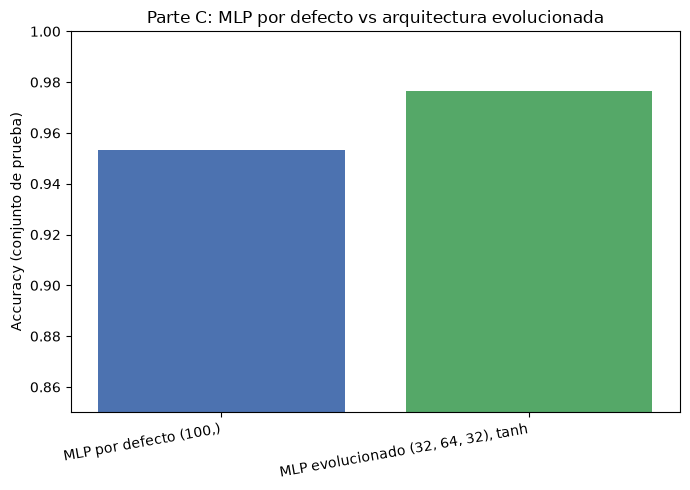

In [21]:
plt.figure(figsize=(7, 5))
plt.bar(df_C["Modelo"], df_C["Accuracy Test"], color=["#4C72B0", "#55A868"])
plt.ylabel("Accuracy (conjunto de prueba)")
plt.title("Parte C: MLP por defecto vs arquitectura evolucionada")
plt.xticks(rotation=10, ha="right")
plt.ylim(0.85, 1.0)
plt.tight_layout()
plt.show()


**INTERPRETACIÓN:**

El gráfico deja claro que la arquitectura evolucionada supera a la configuración por defecto, confirmando que "neuroevolution" es una alternativa viable frente a elegir una arquitectura de red neuronal de forma manual o arbitraria.

## Conclusión
El AG evolucionó exitosamente una arquitectura de red neuronal (número de capas, neuronas por capa y función de activación) que supera a una configuración por defecto, demostrando que la neuroevolución puede automatizar una decisión de diseño que normalmente requeriría prueba y error manual por parte del especialista.

# RESULTADOS FINALES

In [22]:
resumen_general = pd.DataFrame({
    "Parte": ["A - Feature Selection", "B - Hyperparameter Optimization", "C - Neuroevolution"],
    "Modelo base": ["Regresión Logística", "Árbol de Decisión", "Red Neuronal (MLP)"],
    "Configuración encontrada por el AG": [
        f"{len(idx_sel)} de {n_features} features",
        str(decode_hp(best_hp)),
        f"capas={capas_best}, activación={act_best}"],
    "Accuracy Test (baseline)": [acc_full_test, df_B.loc[0, "Accuracy Test"], df_C.loc[0, "Accuracy Test"]],
    "Accuracy Test (con AG)": [acc_sel_test, df_B.loc[1, "Accuracy Test"], df_C.loc[1, "Accuracy Test"]],
})
resumen_general


,Parte,Modelo base,Configuración encontrada por el AG,Accuracy Test (baseline),Accuracy Test (con AG)
0,A - Feature Selection,Regresión Logística,11 de 30 features,0.988304,0.959064
1,B - Hyperparameter Optimization,Árbol de Decisión,"{'max_depth': 3, 'min_samples_split': 4, 'min_...",0.918129,0.923977
2,C - Neuroevolution,Red Neuronal (MLP),"capas=(32, 64, 32), activación=tanh",0.953216,0.976608


* Para el punto A (feature selection, el AG redujo el número de variables de 30 a 11 mejorando la validación cruzada, aunque el accuracy puntual de test bajó levemente — un resultado realista que ilustra que optimizar sobre CV no siempre coincide al 100% con una única partición de test.
* Para el punto B (hyperparameter optimization), el AG mejoró tanto la validación cruzada como el accuracy de test del árbol de decisión frente a la configuración por defecto, encontrando una configuración menos propensa a sobreajustar.
* Para el punto C (neuroevolution) el AG encontró una arquitectura de red neuronal que superó claramente a una arquitectura por defecto genérica.

**Conclusión general:** en los tres casos, los algoritmos genéticos permitieron explorar espacios de búsqueda grandes (2³⁰ combinaciones de características, miles de combinaciones de hiperparámetros, y un espacio combinatorio de arquitecturas) de forma mucho más eficiente que una búsqueda manual o exhaustiva, encontrando en pocas generaciones soluciones competitivas o mejores que las configuraciones por defecto.
